In [25]:
fileName = "wac0000a1c4.vis.even.cub"
import os

os.environ["ISISDATA"] = "/data/isis_data"
os.environ["ISISTESTDATA"] = "//data/isis_data/test_data"
os.environ["ISISROOT"] = "/home/luca/Code/isis_and_co/ISIS3.git/build"
# USGSCSM_LOG_FILE environment variable to the file the log should be written to. To have the logging information printed to the standard output or standard error, set this to stdout or stderr.

# You can adjust how much information is logged by setting the USGSCSM_LOG_LEVEL en


os.environ["USGSCSM_LOG_FILE"] = "stdout"
os.environ["USGSCSM_LOG_LEVEL"] = "error"

import ale
from ale.drivers.lro_drivers import LroLrocWacIsisLabelIsisSpiceDriver, LroLrocWacIsisLabelNaifSpiceDriver
from ale.formatters.formatter import to_isd
import spiceypy as spice
from ale.drivers import AleJsonEncoder

In [26]:
# from ale.util import generate_kernels_from_cube
# kernels = generate_kernels_from_cube(fileName, expand=True, format_as='list')

In [27]:
kernels = ['/home/luca/data/isis_data/lro/kernels/mk/lro_2013.tm']
# kernels = ['/data/JUICE.git/kernels/mk/juice_plan_local.tm']

In [28]:
# from ale.base.label_pds4 import Pds4Label

In [29]:
# JUICE_SPACECRAFT           J2000                  SWITCH          -28000
# JUICE_SPACECRAFT_PLAN      J2000                  CK              -28001
# JUICE_SPACECRAFT_MEAS      J2000                  CK              -28002


In [30]:
with LroLrocWacIsisLabelNaifSpiceDriver(fileName, props = {"kernels": kernels}) as driver:
    # chain = driver.frame_chain
    isisString = to_isd(driver)

    print(driver.projection)



Exception: The ck rotation from frame -85620 can not be found due to no pointing available at requested time 306271739.19310415 or a problem with the frame

In [7]:
# with JuicePds4LabelNaifSpiceDriver(fileName, props = {"kernels": kernels}) as driver:

#     # chain = driver.frame_chain
#     isisString = to_isd(driver)

In [15]:
import json

isis_dict = isisString

json_file = os.path.splitext(fileName)[0] + '.json'

with open(json_file, 'w') as fp:
    json.dump(isis_dict, fp, cls = AleJsonEncoder)
    
with open(json_file, 'r') as fp:
    isis_dict = json.load(fp)
    
isis_dict.keys()

dict_keys(['isis_camera_version', 'image_lines', 'image_samples', 'name_platform', 'name_sensor', 'reference_height', 'name_model', 'starting_ephemeris_time', 'ending_ephemeris_time', 'center_ephemeris_time', 'exposure_duration', 'interframe_delay', 'framelet_order_reversed', 'framelets_flipped', 'framelet_height', 'num_lines_overlap', 'radii', 'body_rotation', 'instrument_pointing', 'naif_keywords', 'detector_sample_summing', 'detector_line_summing', 'focal_length_model', 'detector_center', 'focal2pixel_lines', 'focal2pixel_samples', 'optical_distortion', 'starting_detector_line', 'starting_detector_sample', 'instrument_position', 'sun_position'])

In [16]:
len(isis_dict['instrument_position']['positions'])

2000

In [25]:
!csminit from=janus_cal_sc_0777417466_0096_03_20240819T212236_0020__1_0.cub \
    isd=janus_cal_sc_0777417466_0096_03_20240819T212236_0020__1_0.json \
    PLUGINNAME=UsgsAstroPluginCSM MODELNAME="USGS_ASTRO_PUSH_FRAME_SENSOR_MODEL"  \
    TARGETNAME=MOON
# !cam2map from=janus_cal_sc_0777417466_0096_03_20240819T212236_0020__1_0.cub to=janus_cal_sc_0777417466_0096_03_20240819T212236_0020__1_0_proj.cub

[2024-09-19 17:18:23.028] [usgscsm_logger] [error] Could not construct model [USGS_ASTRO_PUSH_FRAME_SENSOR_MODEL] with error [Model USGS_ASTRO_PUSH_FRAME_SENSOR_MODEL not supported]
[2024-09-19 17:18:23.492] [usgscsm_logger] [error] Could not construct model [USGS_ASTRO_PUSH_FRAME_SENSOR_MODEL] with error [Model USGS_ASTRO_PUSH_FRAME_SENSOR_MODEL not supported]
[2024-09-19 17:18:23.732] [usgscsm_logger] [error] Model USGS_ASTRO_PUSH_FRAME_SENSOR_MODEL not supported with error: [Model USGS_ASTRO_PUSH_FRAME_SENSOR_MODEL not supported]
[2024-09-19 17:18:23.733] [usgscsm_logger] [error] Could not create model [USGS_ASTRO_PUSH_FRAME_SENSOR_MODEL] with error [Model USGS_ASTRO_PUSH_FRAME_SENSOR_MODEL not supported with error: [Model USGS_ASTRO_PUSH_FRAME_SENSOR_MODEL not supported]]
**ERROR** Failed to create a CSMCamera.
**ERROR** Unable to initialize camera model in Camera Factory.
**ERROR** Unable to create CSM camera using CSMState Cube blob.
**PROGRAMMER ERROR** CSM state string attached

In [22]:

from knoten import csm, sensor_utils

In [23]:
# other = '20190303T100344S990_map_iofL2pan_V001-spiceinit.json'

# camera = csm.create_csm(other, verbose=True)

# camera

In [24]:

camera = csm.create_csm(json_file, verbose=True)
# csm.create_csm(fileName)

Trying plugin UsgsAstroPluginCSM
Trying model USGS_ASTRO_FRAME_SENSOR_MODEL
Warning in function UsgsAstroFrameSensorModel::constructStateFromIsd(): "Sensor position does not have 3 values."
Warning in function UsgsAstroFrameSensorModel::constructStateFromIsd(): "Sensor velocity does not have 3 values."
Warning in function UsgsAstroFrameSensorModel::constructStateFromIsd(): "Sensor orientation quaternion does not have 4 values."
Warning in function UsgsAstroFrameSensorModel::constructStateFromIsd(): "Sensor position does not have 3 values."
Warning in function UsgsAstroFrameSensorModel::constructStateFromIsd(): "Sensor velocity does not have 3 values."
Warning in function UsgsAstroFrameSensorModel::constructStateFromIsd(): "Sensor orientation quaternion does not have 4 values."
Warning in function UsgsAstroPlugin::canModelBeConstructedFromISD(): "Could not create model [USGS_ASTRO_FRAME_SENSOR_MODEL] with error [Could not construct model [USGS_ASTRO_FRAME_SENSOR_MODEL] with error [ISD i

In [18]:
camera

<csmapi.csmapi.RasterGM; proxy of <Swig Object of type 'csm::RasterGM *' at 0x74b47016b330> >

In [19]:
import os
import json
import shapely.wkt
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from csmapi import csmapi
import pandas as pd

import ale
from knoten import csm, sensor_utils
from knoten.shape import Ellipsoid
from knoten.illuminator import Illuminator

with open(json_file, 'r') as fp:
    aledict = json.load(fp)

nlines, nsamples = aledict["image_lines"], aledict["image_samples"]

boundary = csm.generate_boundary((nlines, nsamples))

lons, lats, alts = csm.generate_latlon_boundary(camera, boundary)

# plt.rcParams["figure.figsize"] = [5, 5]
# plt.axes().set_aspect('equal','datalim')
# plt.plot(lons, lats)
# plt.xlabel("Longitude (deg)")
# plt.ylabel("Latitude (deg)")
# plt.title("CSM footprint")


Text(0.5, 1.0, 'Body Fixed Footprint')

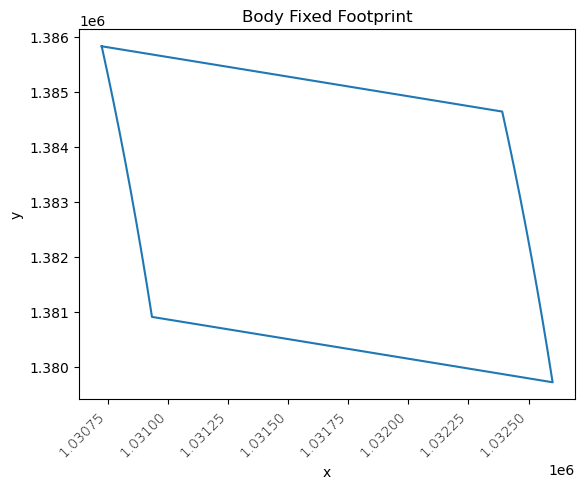

In [20]:
bodyfixed_footprint = csm.generate_bodyfixed_footprint(camera, boundary)

csm_wkt = bodyfixed_footprint.ExportToWkt()

csm_geom = shapely.wkt.loads(csm_wkt)
csm_x, csm_y = csm_geom.geoms[0].exterior.coords.xy

plt.xlabel("x")
plt.ylabel("y")
plt.plot(csm_x, csm_y)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light'
)
plt.title("Body Fixed Footprint")


In [ ]:
image_pt = csmapi.ImageCoord(nlines/2, nsamples/2)
shape = Ellipsoid.from_csm_sensor(camera)
illuminator = Illuminator()

caminfo = {
    "PhaseAngle": sensor_utils.phase_angle(image_pt, camera, shape, illuminator),
    "EmissionAngle": sensor_utils.emission_angle(image_pt, camera, shape),
    "SlantDistance": sensor_utils.slant_distance(image_pt, camera, shape),
    "TargetCenterDistance": sensor_utils.target_center_distance(image_pt, camera),
    "SubSpacecraftLatitude": sensor_utils.sub_spacecraft_point(image_pt, camera).lat,
    "SubSpacecraftLongitude": sensor_utils.sub_spacecraft_point(image_pt, camera).lon,
    "LocalRadius": sensor_utils.local_radius(image_pt, camera, shape),
    "RightAscension": sensor_utils.right_ascension_declination(image_pt, camera)[0],
    "Declination": sensor_utils.right_ascension_declination(image_pt, camera)[1],
    "LineResolution": sensor_utils.line_resolution(image_pt, camera, shape),
    "SampleResolution": sensor_utils.sample_resolution(image_pt, camera, shape),
    "PixelResolution": sensor_utils.pixel_resolution(image_pt, camera, shape),
}

caminfo
